# Test SOTA TSFM(s) (e.g. Toto) on Gifteval multivariate info vs usiong only univariate. Does multivariate help in practice

### Credit: toto/notebooks/inference_tutorial.ipynb

In [1]:
# --- Step 1: Load bizitobs_l2c/H/short data using datasets package ---
import os
import numpy as np
import pandas as pd
from datasets import load_dataset
from toto.data.util.dataset import MaskedTimeseries
from toto.inference.forecaster import TotoForecaster
from toto.model.toto import Toto
import torch
from datetime import datetime, timedelta

import matplotlib
import matplotlib.pyplot as plt
from collections import defaultdict
import pickle
import numbers

/home/roc/01_projects/11_time-series/timeseries-research/.venv/lib/python3.11/site-packages/lightning/fabric/__init__.py:40: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.


In [2]:
print(pd.__version__)

2.2.3


In [54]:
# # experiment_name = 'lag_amount_24'
# # ============================ SimpleTSbench datasets ============================
# data_mode = 'simpletime'  # 'gift-eval' or 'simpletime'
# data_types = [
#     "univariate", 
#     "multivariate", 
#     'multivariate_lagged'
#     ]

# all_data =  [
#     "constant",
#     "exponential",
#     "linear",
#     "noise_patch",
#     "normal",
#     "poisson",
#     "random_walk",
#     "sawtooth",
#     "sine",
#     "staircase"
# ]
# dataset_dir = "../../data/simpletime/datasets"

# ============================ GIFT-eval datasets ============================
data_mode = 'gift-eval'  # 'gift-eval' or 'simpletime'
data_types = [
    'gift_eval'
]

all_data =  [
    "bitbrains_fast_storage/5T",
    "bitbrains_fast_storage/H",
    "bitbrains_rnd/5T",
    "bitbrains_rnd/H",
    # "bizitobs_application/10S", # remove
    "bizitobs_l2c/5T",
    "bizitobs_l2c/H",
    # "bizitobs_service/10S", # remove
    "ett1/15T",
    "ett1/D",
    "ett1/H",
    "ett1/W",
    "ett2/15T",
    "ett2/D",
    "ett2/H",
    "ett2/W",
    "jena_weather/10T",
    "jena_weather/D",
    "jena_weather/H",
    "electricity/15T",
    "electricity/D",
    "electricity/H",
    "electricity/W",
    "hierarchical_sales/D",
    "hierarchical_sales/W",
    "kdd_cup_2018_with_missing/D",
    "kdd_cup_2018_with_missing/H",
    "LOOP_SEATTLE/5T",
    "LOOP_SEATTLE/D",
    "LOOP_SEATTLE/H",
    "M_DENSE/D",
    "M_DENSE/H",
    "SZ_TAXI/15T",
    "SZ_TAXI/H",
    "saugeenday/D",
    "saugeenday/M",
    "saugeenday/W",
    "solar/10T",
    "solar/D",
    "solar/H",
    "solar/W",
    "us_births/D",
    "us_births/M",
    "us_births/W",

]

freq_map = {
            "10S": 10,           # 10 seconds → 10 seconds
            "5T": 5 * 60,        # 5 minutes → 300 seconds
            "10T": 10 * 60,      # 10 minutes → 600 seconds
            "15T": 15 * 60,      # 15 minutes → 900 seconds
            "H": 1 * 3600,       # 1 hour → 3,600 seconds
            "D": 1 * 86400,      # 1 day → 86,400 seconds
            "W": 7 * 86400,      # 1 week → 604,800 seconds
            "M": 30 * 86400,      # 1 month → 2,592,000 seconds
        }
dataset_dir = "../../data" # for gift-eval
# dataset_dir = "/home/roc/01_projects/11_time-series/timeseries-research/data"

samples_per_batch = 16
forecast_log = {}
metrics_log = []
context_pct = 0.8
prediction_pct = 0.2
context_length_cap = 512
prediction_length_cap = 96 # [96, 192, 336, 720]
UNIVAR_N = 10  # For some univariate datasets where the entire series is broken into multiple rows, only use the first N rows
DEVICE = "cuda"

def load_data(dataset_name, data_type, freq='H', data_mode='simpletime'):
    global dataset_dir
    # Path to Arrow file directory (datasets expects a directory, not a file)
    if data_mode == 'simpletime':
        DATASET_DIR = f"{dataset_dir}/{data_type}/{dataset_name}"
    else:
        DATASET_DIR = f"{dataset_dir}/{data_type}/{dataset_name}/{freq}"
    # Load the dataset using the datasets package
    ds = load_dataset('arrow', data_files={"train": os.path.join(DATASET_DIR, "data-00000-of-00001.arrow")})
    # Convert to pandas DataFrame for inspection
    df = ds['train'].to_pandas()
    return df


def compute_mae(forecast, target):
    # forecast.samples: shape (1, n_variates, prediction_length, n_samples)
    # target: shape (n_variates, prediction_length)
    pred = np.median(forecast.samples.squeeze().cpu().numpy(), axis=-1)
    mae_per_var = np.mean(np.abs(pred - target), axis=1)
    mae_overall = np.mean(mae_per_var)
    return list(map(lambda x: round(x, 4), mae_per_var)), round(mae_overall, 4)

def compute_mean_bias(input_mean, forecast, target):
    """
    Compute two metrics that quantifies mean bias: 
        Mean Attraction Ratio (MAR): mean(|target - input_mean|) / mean(|pred - input_mean|)
            Higher ratio means more mean biased prediction.
        Mean Bias Ratio (MBR): How often the prediction is biased towards the mean.
            MBR = 1 means always biased towards the mean.
            MBR close to 0.5 means no bias.
            MBR close to 0 means always biased away from the mean.
    """
    # input_mean: shape (n_variates, 1)
    # forecast.samples: shape (1, n_variates, prediction_length, n_samples)
    # target: shape (n_variates, prediction_length)
    pred = np.median(forecast.samples.squeeze().cpu().numpy(), axis=-1) # pred shape: (n_variates, prediction_length)
    # Mean Attraction Ratio (MAR)
    # The bigger the ratio, the more mean biased the prediction is
    pred_mean_diff = np.mean(np.abs(pred - input_mean), axis=1)
     # To avoid division by zero
    if np.any(pred_mean_diff == 0):
        pred_mean_diff = np.where(pred_mean_diff == 0, 1e-6, pred_mean_diff)
        pred_mean_diff = 1e-6
    mean_bias_ratio_per_var = np.mean(np.abs(target - input_mean), axis=1) / pred_mean_diff # shape: (n_variates,)
    mean_bias_ratio_overall = np.mean(mean_bias_ratio_per_var)
    
    # Mean Bias Ratio (MBR)
    # MBR: fraction of steps where prediction is biased towards the mean
    # Compare the sign of (target - input_mean) and (target - pred)
    mbr_per_var = np.mean(np.sign(target - input_mean) == np.sign(target - pred), axis=1)
    mbr_overall = np.mean(mbr_per_var)
    return list(map(lambda x: round(x, 4), mean_bias_ratio_per_var)), round(mean_bias_ratio_overall, 4), list(map(lambda x: round(x, 4), mbr_per_var)), round(mbr_overall, 4)


def gen_dates_and_timestamp_seconds(input_series: torch.Tensor, df: pd.DataFrame, target_list: list, freq_map: dict = freq_map) -> torch.Tensor:
    """
    Generate dates for the entire df and timestamp seconds for each time step in input_series.
    """
    n_var, n_step = len(target_list), len(target_list[0])
    freq = df['freq'][0].split("-")[0] # To handle cases like "W-THU"
    start_time = df['start'][0]
    # Parse start_time to datetime if needed
    if isinstance(start_time, str):
        start_dt = datetime.fromisoformat(start_time)
    else:
        start_dt = start_time.to_pydatetime() if hasattr(start_time, "to_pydatetime") else start_time
    # Map freq string to seconds
    if freq not in freq_map:
        raise ValueError(f"Unsupported freq: {freq}")
    step_seconds = freq_map[freq]
    # Get start timestamp in seconds since epoch
    start_ts = int(start_dt.timestamp())
    # Generate timestamps for each step
    timestamps = torch.arange(n_step) * step_seconds + start_ts
    dates = pd.to_datetime(timestamps, unit='s')
    n_step_input = input_series.shape[1]
    # Expand to (n_var, n_step_input)
    timestamp_seconds = timestamps[:n_step_input].unsqueeze(0).expand(n_var, n_step_input).to(input_series.device)
    return dates, timestamp_seconds

def proc_na(target_list):
    """
    Remove any heading and trailing NaNs from each series in target_list.
    Do forward filling to fill any NaNs in the middle of the series.
    """
    proc_target_list = []
    for series in target_list:
        series = pd.Series(series)
        # Remove heading and trailing NaNs
        # And print out the number of leading and trailing NaNs removed
        leading_nans = series.first_valid_index()
        trailing_nans = series.last_valid_index()
        if not ((leading_nans == 0) and (trailing_nans == len(series) - 1)):
            print(f"Removed {leading_nans} leading NaNs and {len(series) - trailing_nans - 1} trailing NaNs from series.")
            series = series.loc[leading_nans:trailing_nans]
        if series.empty:
            raise ValueError("Series is empty after removing heading and trailing NaNs.")
        # Forward fill to fill any NaNs in the middle
        # Also print out the number of NaNs filled
        num_nans = series.isna().sum()
        if num_nans > 0:
            print(f"Forward filled {num_nans} NaNs in the middle of the series.")
        series = series.ffill()
        proc_target_list.append(series.to_numpy())
    return proc_target_list
    

def main(dataset_name, context_pct, prediction_pct, data_type, data_mode, freq='H', ):
    global forecast_log, samples_per_batch, freq_map, DEVICE, metrics_log, context_length_cap, prediction_length_cap
    """    Prepares the input series for Toto from the DataFrame.
    """
    if data_mode == 'simpletime':
        df = load_data(dataset_name, data_type, freq, data_mode)
    else:
        dataset_name, freq = dataset_name.split('/')
        df = load_data(dataset_name, data_type, freq, data_mode)
    # --- Step 2: Prepare target array for Toto (shape: [num_variables, series_length]) ---
    target_list = df['target'][0]
    if isinstance(target_list[0], numbers.Number):
        target_list = [target_list]  # Wrap in list to make it multivariate with one variable
    # if len(target_list) > 1:
    #     target_list = target_list[:UNIVAR_N] # For univariate_special datasets, only use the first N series for testing
    # else:
    #     target_list = target_list[0]
    #     if isinstance(target_list[0], numbers.Number):
    #         target_list = [target_list]  # Wrap in list to make it multivariate with one variable
    print(len(target_list), len(target_list[0]))
    target_list = proc_na(target_list)
    n_variates = len(target_list)
    n_step = len(target_list[0])
    print("total n_step in data:", n_step)


    interval = freq_map[freq]
    context_length = min(int(n_step * context_pct), context_length_cap) # Cap context length for fast experiment
    prediction_length = min(int(n_step * prediction_pct), prediction_length_cap) # Cap prediction length for fast experiment
    idx_inputs_start = -(context_length+prediction_length)
    idx_inputs_end = -prediction_length
    inputs = np.stack([x[idx_inputs_start:idx_inputs_end] for x in target_list])
    target = np.stack([x[idx_inputs_end:] for x in target_list])

    # Debug: Check for NaNs/Infs and shape in inputs
    print("inputs shape:", inputs.shape)
    print("target shape:", target.shape)
    print("inputs dtype:", inputs.dtype)
    print("Any NaNs in inputs?", np.isnan(inputs).any())
    print("Any Infs in inputs?", np.isinf(inputs).any())
    print("\n\n")
    
    input_series = torch.from_numpy(inputs).to(torch.float).to(DEVICE)
    input_series.shape
    dates, timestamp_seconds = gen_dates_and_timestamp_seconds(input_series, df, target_list)
    time_interval_seconds = torch.full((n_variates,), interval).to(input_series.device)
    # start_timestamp_seconds = timestamp_seconds[:, 0]
    
    id_mask_multi = torch.zeros_like(input_series)
    id_mask_uni = torch.arange(input_series.shape[0], device=input_series.device).unsqueeze(1).expand_as(input_series)
    
    input_ts_uni = MaskedTimeseries(
        series=input_series,
        # The padding mask should be the same shape as the input series.
        # It should be 0 to indicate padding and 1 to indicate valid values.
        padding_mask=torch.full_like(input_series, True, dtype=torch.bool),
        # The ID mask is used for packing unrelated time series along the Variate dimension.
        # This is used in training, and can also be useful for large-scale batch inference in order to
        # process time series of different numbers of variates using batches of a fixed shape.
        # The ID mask controls the channel-wise attention; variates with different IDs cannot attend to each other.
        # If you're not using packing, just set this to zeros.
        id_mask=id_mask_uni,
        # As mentioned above, these timestamp features are not currently used by the model;
        # however, they are reserved for future releases.
        timestamp_seconds=timestamp_seconds,
        time_interval_seconds=time_interval_seconds,
    )


    input_ts_multi = MaskedTimeseries(
        series=input_series,
        padding_mask=torch.full_like(input_series, True, dtype=torch.bool),
        id_mask=id_mask_multi,
        timestamp_seconds=timestamp_seconds,
        time_interval_seconds=time_interval_seconds,
    )


    toto = Toto.from_pretrained('Datadog/Toto-Open-Base-1.0')
    toto.to(DEVICE)
    # torch.cuda.empty_cache()

    # Optionally enable Torch's JIT compilation to speed up inference. This is mainly
    # helpful if you want to perform repeated inference, as the JIT compilation can
    # take time to wrm up.
    toto.compile()

    forecaster = TotoForecaster(toto.model)
    forecast_uni = forecaster.forecast(
        input_ts_uni,
        # We can set any number of timesteps into the future that we'd like to forecast. Because Toto is an autoregressive model,
        # the inference time will be longer for longer forecasts. 
        prediction_length=prediction_length,
        # TOTOForecaster draws samples from a predicted parametric distribution. The more samples, the more stable and accurate the prediction.
        # This is especially important if you care about accurate prediction intervals in the tails.
        # Toto's evaluations were performed using 256 samples. Set this according to your compute budget.
        num_samples=256,
        # TOTOForecaster also handles batching the samples in order to control memory usage.
        # Set samples_per_batch as high as you can without getting OOMs for maximum performance.
        # If you're doing batch inference, the effective batch size sent to the model is (batch_size x samples_per_batch).
        # In this notebook, we're doing unbatched inference, so the effective batch size is samples_per_batch.
        samples_per_batch=samples_per_batch,
        # KV cache should significantly speed up inference, and in most cases should reduce memory usage too.
        use_kv_cache=True,
    )

    forecast_multi = forecaster.forecast(
        input_ts_multi,
        prediction_length=prediction_length,
        num_samples=256,
        samples_per_batch=samples_per_batch,
        use_kv_cache=True,
    )
    if data_type not in forecast_log:
        forecast_log[data_type] = {}
    if dataset_name not in forecast_log[data_type]:
        forecast_log[data_type][dataset_name] = {}
    forecast_log[data_type][dataset_name][freq] = {
        'univariate': forecast_uni,
        'multivariate': forecast_multi,
        'idx_inputs_start': idx_inputs_start,
        'idx_inputs_end': idx_inputs_end,
        'dates': dates,
        'n_variates': n_variates,
        'inputs': inputs,
        'target': target,
    }
    
    mae_uni, mae_uni_overall = compute_mae(forecast_uni, target)
    mae_multi, mae_multi_overall = compute_mae(forecast_multi, target)
    input_mean = input_series.mean(dim=1, keepdim=True).cpu().numpy()
    mar_uni, mar_uni_overall, mbr_uni, mbr_uni_overall = compute_mean_bias(input_mean, forecast_uni, target)
    mar_multi, mar_multi_overall, mbr_multi, mbr_multi_overall = compute_mean_bias(input_mean, forecast_multi, target)

    features = [f"var_{i}" for i in range(n_variates)] + ['overall']
    metrics = pd.DataFrame({
        'datatype': [data_type for _ in range(n_variates + 1)],
        'dataset': [dataset_name for _ in range(n_variates + 1)],
        'frequency': [freq for _ in range(n_variates + 1)],
        'feature': features,
        'mae_uni': list(mae_uni) + [mae_uni_overall],
        'mae_multi': list(mae_multi) + [mae_multi_overall],
        'mar_uni': list(mar_uni) + [mar_uni_overall],
        'mar_multi': list(mar_multi) + [mar_multi_overall],
        'mbr_uni': list(mbr_uni) + [mbr_uni_overall],
        'mbr_multi': list(mbr_multi) + [mbr_multi_overall],
        'context_length': [context_length for _ in range(n_variates + 1)],
        'prediction_length': [prediction_length for _ in range(n_variates + 1)],
    })

    metrics_log.append(metrics)
    return

In [55]:
experiment_name = f'mean_bias_experiment_all-gift-eval-datasets_context-{context_length_cap}_prediction-{prediction_length_cap}'

In [56]:
from tqdm import tqdm
for data_type in tqdm(data_types):
    for dataset_name in tqdm(all_data):
        print(f"Processing {data_type} - {dataset_name}")
        main(dataset_name, context_pct, prediction_pct, data_type, data_mode)

  0%|          | 0/1 [00:00<?, ?it/s]

Processing gift_eval - bitbrains_fast_storage/5T
2 8640
Forward filled 21 NaNs in the middle of the series.
Forward filled 21 NaNs in the middle of the series.
total n_step in data: 8640
inputs shape: (2, 512)
target shape: (2, 96)
inputs dtype: float32
Any NaNs in inputs? False
Any Infs in inputs? False





Processing gift_eval - bitbrains_fast_storage/H
2 721
total n_step in data: 721
inputs shape: (2, 512)
target shape: (2, 96)
inputs dtype: float32
Any NaNs in inputs? False
Any Infs in inputs? False





Processing gift_eval - bitbrains_rnd/5T
2 8640
Removed 4281 leading NaNs and 0 trailing NaNs from series.
Forward filled 386 NaNs in the middle of the series.
Removed 4281 leading NaNs and 0 trailing NaNs from series.
Forward filled 386 NaNs in the middle of the series.
total n_step in data: 4359
inputs shape: (2, 512)
target shape: (2, 96)
inputs dtype: float32
Any NaNs in inputs? False
Any Infs in inputs? False





Processing gift_eval - bitbrains_rnd/H
2 720
Removed 356 leading NaNs and 0 trailing NaNs from series.
Forward filled 30 NaNs in the middle of the series.
Removed 356 leading NaNs and 0 trailing NaNs from series.
Forward filled 30 NaNs in the middle of the series.
total n_step in data: 364
inputs shape: (2, 291)
target shape: (2, 72)
inputs dtype: float32
Any NaNs in inputs? False
Any Infs in inputs? False





...

Processing gift_eval - solar/W
1 52
total n_step in data: 52
inputs shape: (1, 41)
target shape: (1, 10)
inputs dtype: float32
Any NaNs in inputs? False
Any Infs in inputs? False





Processing gift_eval - us_births/D
1 7305
total n_step in data: 7305
inputs shape: (1, 512)
target shape: (1, 96)
inputs dtype: float32
Any NaNs in inputs? False
Any Infs in inputs? False





Processing gift_eval - us_births/M
1 240
total n_step in data: 240
inputs shape: (1, 192)
target shape: (1, 48)
inputs dtype: float32
Any NaNs in inputs? False
Any Infs in inputs? False





Processing gift_eval - us_births/W
1 1043
total n_step in data: 1043
inputs shape: (1, 512)
target shape: (1, 96)
inputs dtype: float32
Any NaNs in inputs? False
Any Infs in inputs? False





100%|██████████| 1/1 [01:55<00:00, 115.47s/it]


In [57]:
metrics_combine = pd.concat(metrics_log, ignore_index=True)
# Create output directories if they don't exist
os.makedirs(f"outputs/{experiment_name}", exist_ok=True)
metrics_combine.to_csv(f"outputs/{experiment_name}/metrics_all.csv", index=False)
metrics_combine.query("feature == 'overall'").to_csv(f"outputs/{experiment_name}/metrics_agg.csv", index=False)

In [58]:
with open(f"outputs/{experiment_name}/forecast_log.pkl", "wb") as f:
    pickle.dump(forecast_log, f)

In [68]:
# read back
with open(f"outputs/{experiment_name}/forecast_log.pkl", "rb") as f:
    forecast_log = pickle.load(f)

In [36]:
metrics_combine

,datatype,dataset,frequency,feature,mae_uni,mae_multi,mar_uni,mar_multi,mbr_uni,mbr_multi,context_length,prediction_length
0,gift_eval,bitbrains_fast_storage,5T,var_0,16.948000,16.764500,13.3610,13.3259,0.9427,0.9167,512,192
1,gift_eval,bitbrains_fast_storage,5T,var_1,0.328000,0.323500,12.7142,13.3325,0.9271,0.9323,512,192
2,gift_eval,bitbrains_fast_storage,5T,overall,8.638000,8.544000,13.0376,13.3292,0.9349,0.9245,512,192
3,gift_eval,bitbrains_fast_storage,H,var_0,23.424000,23.543900,2.0485,2.0022,0.8542,0.8333,512,144
4,gift_eval,bitbrains_fast_storage,H,var_1,0.456800,0.455900,2.0018,1.9913,0.8403,0.8403,512,144
...,...,...,...,...,...,...,...,...,...,...,...,...
203,gift_eval,us_births,D,overall,422.575287,419.003113,0.9972,0.9931,0.5208,0.5104,512,192
204,gift_eval,us_births,M,var_0,16151.331055,16558.845703,1.8910,1.8749,0.9583,0.9583,192,48
205,gift_eval,us_births,M,overall,16151.331055,16558.845703,1.8910,1.8749,0.9583,0.9583,192,48
206,gift_eval,us_births,W,var_0,1783.595581,1859.923340,1.2539,1.2795,0.7292,0.7500,512,192


In [7]:
def plot_forecasts(forecast_log, dataset, freq, mode, data_type):
    idx_inputs_start = forecast_log[data_type][dataset][freq]['idx_inputs_start']
    idx_inputs_end = forecast_log[data_type][dataset][freq]['idx_inputs_end']
    dates = forecast_log[data_type][dataset][freq]['dates']
    n_variates = forecast_log[data_type][dataset][freq]['n_variates']
    inputs = forecast_log[data_type][dataset][freq]['inputs']
    target = forecast_log[data_type][dataset][freq]['target']
    forecast = forecast_log[data_type][dataset][freq][mode]

    DARK_GREY = "#1c2b34"
    BLUE = "#3598ec"
    PURPLE = "#7463e1"
    LIGHT_PURPLE = "#d7c3ff"
    PINK = "#ff0099"

    matplotlib.rc("axes", edgecolor=DARK_GREY)
    fig = plt.figure(figsize=(12, 6), layout="tight", dpi=150)
    plt.suptitle(f"Toto Forecasts ({dataset}/{freq}) - {mode}")

    for i in range(n_variates):
        # Configure axes
        feature = f"var_{i}"
        plt.subplot(n_variates, 1, i + 1)
        if i != 6:
            # only show x tick labels on the bottom subplot
            fig.gca().set_xticklabels([])
        fig.gca().tick_params(axis="x", color=DARK_GREY, labelcolor=DARK_GREY)
        fig.gca().tick_params(axis="y", color=DARK_GREY, labelcolor=DARK_GREY)
        fig.gca().yaxis.set_label_position("right")
        plt.ylabel(feature)
        # plt.xlim(input_df.date.iloc[-960], target_df.date.iloc[-1])
        plt.axvline(dates[idx_inputs_end], color=PINK, linestyle=":")
        
        # Plot ground truth
        plt.plot(dates[idx_inputs_start: idx_inputs_end], np.asarray(inputs[i]).flatten(), color=BLUE)
        plt.plot(dates[idx_inputs_end:], np.asarray(target[i]).flatten(), color=BLUE)

        # Plot point forecasts
        samples_np = forecast.samples.cpu().numpy()  # shape: (1, n_variates, pred_len, n_samples) or (n_variates, pred_len, n_samples)
        if samples_np.ndim == 4:
            samples_np = samples_np.squeeze(0)  # remove batch dim if present
        # samples_np: (n_variates, pred_len, n_samples)
        point_forecast = np.median(samples_np[i], axis=-1)  # shape: (prediction_length,)
        plt.plot(
            dates[idx_inputs_end:],
            point_forecast,
            color=PURPLE,
            linestyle="--",
        )

        # Plot quantiles
        alpha = 0.05
        lower = np.quantile(samples_np[i], alpha, axis=-1)
        upper = np.quantile(samples_np[i], 1 - alpha, axis=-1)
        plt.fill_between(
            dates[idx_inputs_end:],
            lower,
            upper,
            color=LIGHT_PURPLE,
            alpha=0.8,
        )
        
# plot_forecasts(forecast_log, 'staircase', freq='H', mode='multivariate', data_type='multivariate_lagged')

In [8]:
all_data

['kdd_cup_2018_with_missing/D']

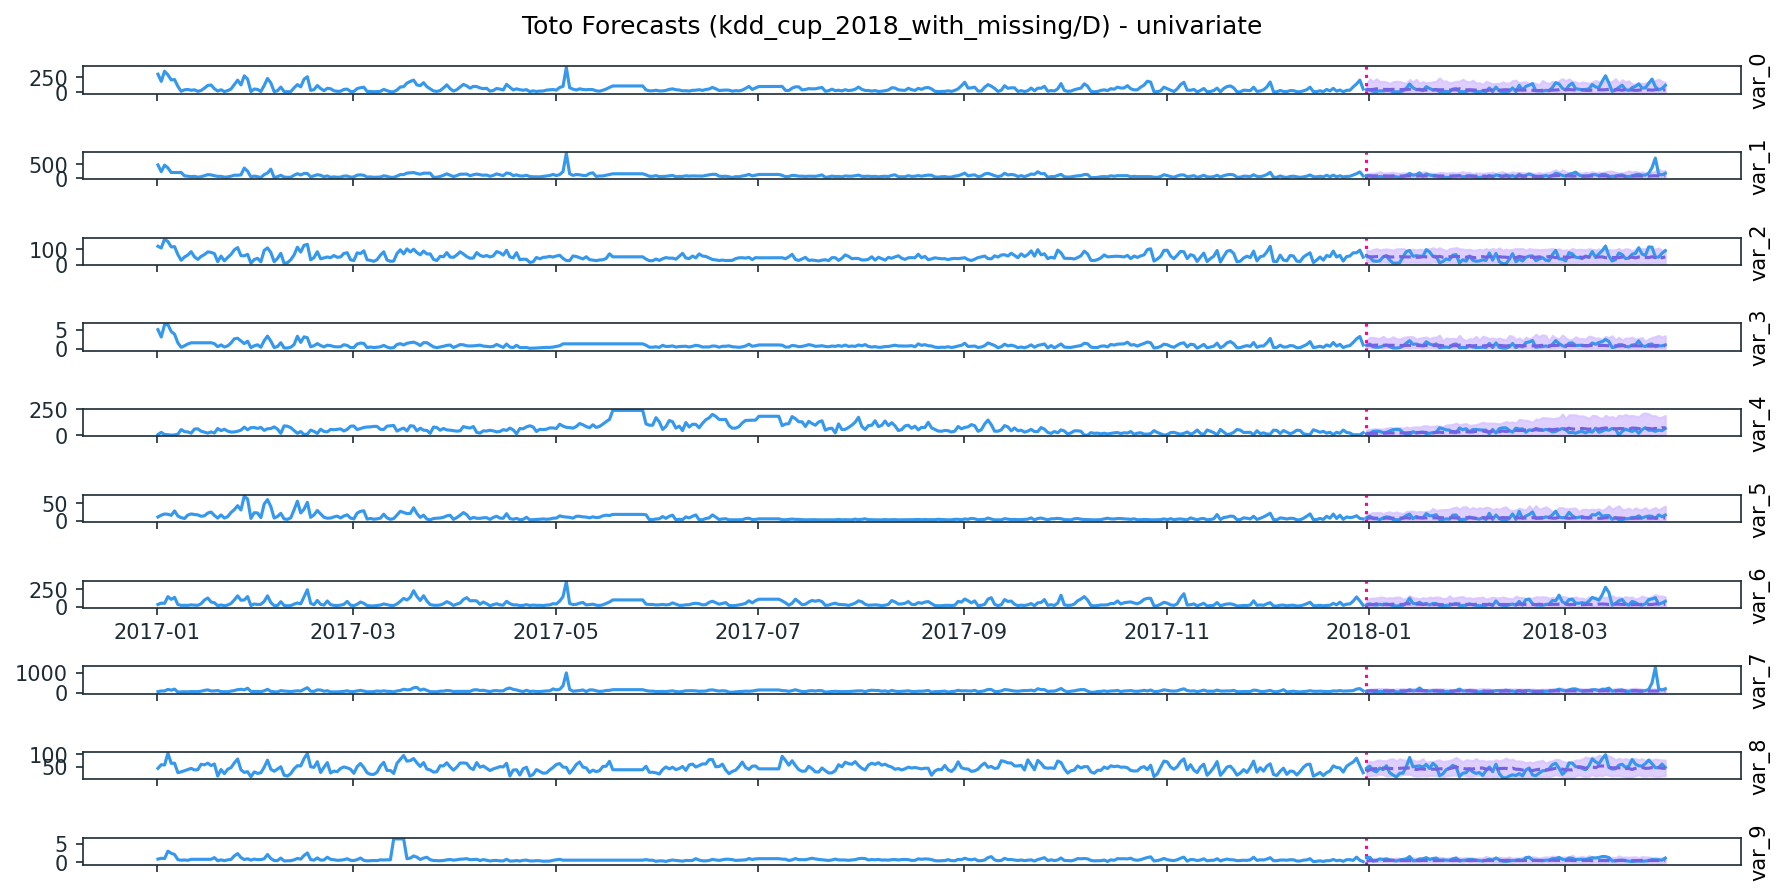

In [9]:
plot_forecasts(forecast_log, 'kdd_cup_2018_with_missing', freq='D', mode='univariate', data_type='gift_eval')

In [10]:
from PIL import Image

def save_all_forecast_plots_with_aggregates(forecast_log, output_dir):
    import os
    import matplotlib
    import matplotlib.pyplot as plt
    import numpy as np

    os.makedirs(output_dir, exist_ok=True)
    indiv_dir = os.path.join(output_dir, "individual_plots")
    os.makedirs(indiv_dir, exist_ok=True)
    data_types = list(forecast_log.keys())
    modes = ["univariate", "multivariate"]

    VAR_COLORS = [
        "#3598ec", "#ff0099", "#7463e1", "#e67e22", "#2ecc71",
        "#e74c3c", "#1abc9c", "#f1c40f", "#34495e", "#95a5a6"
    ]
    QUANTILE_ALPHA = 0.2

    for data_type in forecast_log:
        for dataset in forecast_log[data_type]:
            for freq in forecast_log[data_type][dataset]:
                for mode in modes:
                    if mode not in forecast_log[data_type][dataset][freq]:
                        continue
                    entry = forecast_log[data_type][dataset][freq]
                    idx_inputs_start = entry['idx_inputs_start']
                    idx_inputs_end = entry['idx_inputs_end']
                    dates = entry['dates']
                    n_variates = entry['n_variates']
                    inputs = entry['inputs']
                    target = entry['target']
                    forecast = entry[mode]
                    DARK_GREY = "#1c2b34"
                    matplotlib.rc("axes", edgecolor=DARK_GREY)

                    # --- For multivariate_lagged, save both merged and split versions ---
                    if data_type == "multivariate_lagged":
                        # Merged: all variates in one plot
                        fig_merged = plt.figure(figsize=(12, 6), layout="tight", dpi=150)
                        plt.suptitle(f"Toto Forecasts - {data_type} - {dataset} - {mode} (merged)")
                        for i in range(n_variates):
                            color = VAR_COLORS[i % len(VAR_COLORS)]
                            plt.plot(dates[idx_inputs_start: idx_inputs_end], np.asarray(inputs[i]).flatten(), color=color, label=f"var_{i} input")
                            plt.plot(dates[idx_inputs_end:], np.asarray(target[i]).flatten(), color=color, label=f"var_{i} target")
                            samples_np = forecast.samples.cpu().numpy()
                            if samples_np.ndim == 4:
                                samples_np = samples_np.squeeze(0)
                            point_forecast = np.median(samples_np[i], axis=-1)
                            plt.plot(dates[idx_inputs_end:], point_forecast, color=color, linestyle="--", label=f"var_{i} forecast")
                            alpha = 0.05
                            lower = np.quantile(samples_np[i], alpha, axis=-1)
                            upper = np.quantile(samples_np[i], 1 - alpha, axis=-1)
                            plt.fill_between(dates[idx_inputs_end:], lower, upper, color=color, alpha=QUANTILE_ALPHA)
                        plt.axvline(dates[idx_inputs_end], color="#ff0099", linestyle=":")
                        plt.legend(loc="upper left", fontsize="small", ncol=2)
                        fname_merged = f"{data_type}_mode_{mode}_{dataset}_merged.png"
                        fpath_merged = os.path.join(indiv_dir, fname_merged)
                        plt.savefig(fpath_merged)
                        plt.close(fig_merged)

                        # Split: per-variate subplots
                        PURPLE = "#7463e1"
                        LIGHT_PURPLE = "#d7c3ff"
                        PINK = "#ff0099"
                        BLUE = "#3598ec"
                        fig_split = plt.figure(figsize=(12, 6), layout="tight", dpi=150)
                        plt.suptitle(f"Toto Forecasts - {data_type} - {dataset} - {mode} (split)")
                        for i in range(n_variates):
                            feature = f"var_{i}"
                            plt.subplot(n_variates, 1, i + 1)
                            if i != n_variates - 1:
                                fig_split.gca().set_xticklabels([])
                            fig_split.gca().tick_params(axis="x", color=DARK_GREY, labelcolor=DARK_GREY)
                            fig_split.gca().tick_params(axis="y", color=DARK_GREY, labelcolor=DARK_GREY)
                            fig_split.gca().yaxis.set_label_position("right")
                            plt.ylabel(feature)
                            plt.axvline(dates[idx_inputs_end], color=PINK, linestyle=":")
                            plt.plot(dates[idx_inputs_start: idx_inputs_end], inputs[i], color=BLUE)
                            plt.plot(dates[idx_inputs_end:], target[i], color=BLUE)
                            samples_np = forecast.samples.cpu().numpy()
                            if samples_np.ndim == 4:
                                samples_np = samples_np.squeeze(0)
                            point_forecast = np.median(samples_np[i], axis=-1)
                            plt.plot(dates[idx_inputs_end:], point_forecast, color=PURPLE, linestyle="--")
                            alpha = 0.05
                            lower = np.quantile(samples_np[i], alpha, axis=-1)
                            upper = np.quantile(samples_np[i], 1 - alpha, axis=-1)
                            plt.fill_between(dates[idx_inputs_end:], lower, upper, color=LIGHT_PURPLE, alpha=0.8)
                        fname_split = f"{data_type}_mode_{mode}_{dataset}_split.png"
                        fpath_split = os.path.join(indiv_dir, fname_split)
                        plt.savefig(fpath_split)
                        plt.close(fig_split)
                    else:
                        # Original per-variate subplot for other data_types
                        PURPLE = "#7463e1"
                        LIGHT_PURPLE = "#d7c3ff"
                        PINK = "#ff0099"
                        BLUE = "#3598ec"
                        fig = plt.figure(figsize=(12, 6), layout="tight", dpi=150)
                        plt.suptitle(f"Toto Forecasts - {data_type} - {dataset} - {mode}")
                        for i in range(n_variates):
                            feature = f"var_{i}"
                            plt.subplot(n_variates, 1, i + 1)
                            if i != n_variates - 1:
                                fig.gca().set_xticklabels([])
                            fig.gca().tick_params(axis="x", color=DARK_GREY, labelcolor=DARK_GREY)
                            fig.gca().tick_params(axis="y", color=DARK_GREY, labelcolor=DARK_GREY)
                            fig.gca().yaxis.set_label_position("right")
                            plt.ylabel(feature)
                            plt.axvline(dates[idx_inputs_end], color=PINK, linestyle=":")
                            plt.plot(dates[idx_inputs_start: idx_inputs_end], inputs[i], color=BLUE)
                            plt.plot(dates[idx_inputs_end:], target[i], color=BLUE)
                            samples_np = forecast.samples.cpu().numpy()
                            if samples_np.ndim == 4:
                                samples_np = samples_np.squeeze(0)
                            point_forecast = np.median(samples_np[i], axis=-1)
                            plt.plot(dates[idx_inputs_end:], point_forecast, color=PURPLE, linestyle="--")
                            alpha = 0.05
                            lower = np.quantile(samples_np[i], alpha, axis=-1)
                            upper = np.quantile(samples_np[i], 1 - alpha, axis=-1)
                            plt.fill_between(dates[idx_inputs_end:], lower, upper, color=LIGHT_PURPLE, alpha=0.8)
                        fname = f"{data_type}_mode_{mode}_{dataset}.png"
                        fpath = os.path.join(indiv_dir, fname)
                        plt.savefig(fpath)
                        plt.close(fig)

    # Save aggregated plots for each data_type and mode by stacking images
    for data_type in data_types:
        for mode in modes:
            # Split version
            img_files_split = [os.path.join(indiv_dir, f) for f in os.listdir(indiv_dir)
                               if f.startswith(f"{data_type}_mode_{mode}_") and f.endswith("_split.png")]
            if img_files_split:
                imgs = [Image.open(f) for f in img_files_split]
                min_width = min(img.width for img in imgs)
                imgs = [img.resize((min_width, int(img.height * min_width / img.width))) for img in imgs]
                total_height = sum(img.height for img in imgs)
                agg_img = Image.new('RGB', (min_width, total_height), color=(255,255,255))
                y_offset = 0
                for img in imgs:
                    agg_img.paste(img, (0, y_offset))
                    y_offset += img.height
                agg_fname = f"data-{data_type}_mode-{mode}_ALLDATA_split.png"
                agg_fpath = os.path.join(output_dir, agg_fname)
                agg_img.save(agg_fpath)
            # Merged version
            img_files_merged = [os.path.join(indiv_dir, f) for f in os.listdir(indiv_dir)
                                if f.startswith(f"{data_type}_mode_{mode}_") and f.endswith("_merged.png")]
            if img_files_merged:
                imgs = [Image.open(f) for f in img_files_merged]
                min_width = min(img.width for img in imgs)
                imgs = [img.resize((min_width, int(img.height * min_width / img.width))) for img in imgs]
                total_height = sum(img.height for img in imgs)
                agg_img = Image.new('RGB', (min_width, total_height), color=(255,255,255))
                y_offset = 0
                for img in imgs:
                    agg_img.paste(img, (0, y_offset))
                    y_offset += img.height
                agg_fname = f"data-{data_type}_mode-{mode}_ALLDATA_merged.png"
                agg_fpath = os.path.join(output_dir, agg_fname)
                agg_img.save(agg_fpath)
            # For other data_types, keep original aggregation
            if data_type != "multivariate_lagged":
                img_files = [os.path.join(indiv_dir, f) for f in os.listdir(indiv_dir)
                             if f.startswith(f"{data_type}_mode_{mode}_") and f.endswith(".png")]
                if img_files:
                    imgs = [Image.open(f) for f in img_files]
                    min_width = min(img.width for img in imgs)
                    imgs = [img.resize((min_width, int(img.height * min_width / img.width))) for img in imgs]
                    total_height = sum(img.height for img in imgs)
                    agg_img = Image.new('RGB', (min_width, total_height), color=(255,255,255))
                    y_offset = 0
                    for img in imgs:
                        agg_img.paste(img, (0, y_offset))
                        y_offset += img.height
                    agg_fname = f"data-{data_type}_mode-{mode}_ALLDATA.png"
                    agg_fpath = os.path.join(output_dir, agg_fname)
                    agg_img.save(agg_fpath)
    print(f"All individual plots saved to {indiv_dir} and aggregate plots to {output_dir}")

In [ ]:
# save_all_forecast_plots_with_aggregates(forecast_log, output_dir=f"outputs/{experiment_name}")

All individual plots saved to outputs/lag_amount_24/individual_plots and aggregate plots to outputs/lag_amount_24
